Ejercicio 1-filtro pasa banda


In [92]:
pip install neurokit2

In [93]:
import pandas as pd
import numpy as np
import neurokit2 as nk


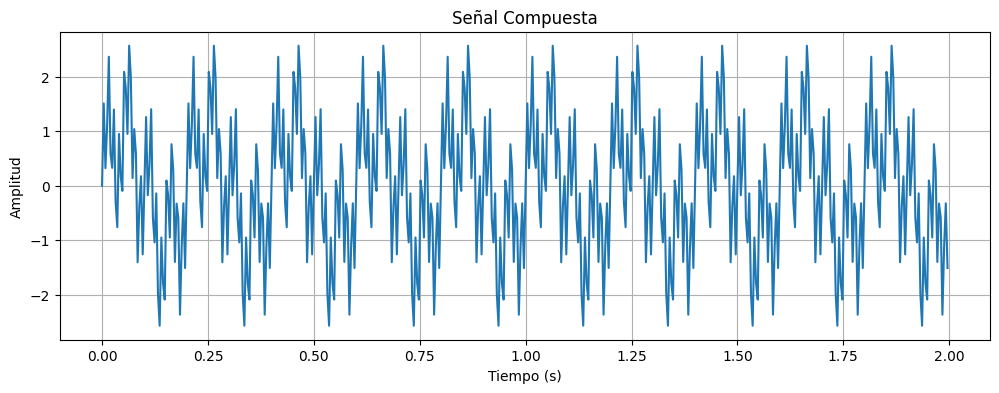

In [94]:
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import firwin, lfilter

fs_new = 250
duration = 2 # Duración de la señal en segundos
t = np.linspace(0, duration, int(fs_new * duration), endpoint=False)

#Generar las tres señales
signal_5hz = np.sin(2 * np.pi * 5 * t)
signal_20hz = np.sin(2 * np.pi * 20 * t)
signal_80hz = np.sin(2 * np.pi * 80 * t)

signal = signal_5hz + signal_20hz + signal_80hz

#Plot
plt.figure(figsize=(12, 4))
plt.plot(t, signal)
plt.title('Señal Compuesta')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

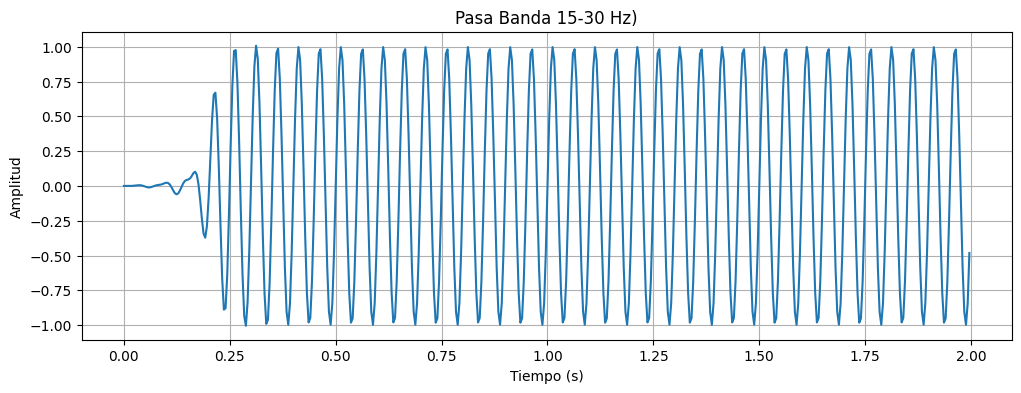

In [95]:
#Filtro pasa banda deseado
fc_low = 15
fc_high = 30
N_filter = 101

#Diseño del filtro
fir_bandpass = firwin(N_filter,[fc_low, fc_high], pass_zero = False, fs=fs_new)
#Aplicando el filtro
filtered_composite_signal = lfilter(fir_bandpass, [1.0], signal)

#Visualizar la señal filtrada en el dominio del tiempo
plt.figure(figsize=(12, 4))
plt.plot(t, filtered_composite_signal)
plt.title('Pasa Banda 15-30 Hz)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

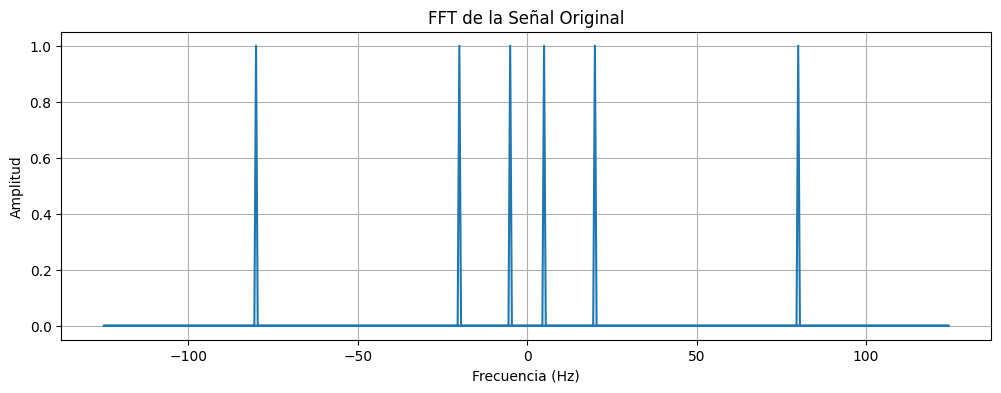

In [96]:
def plot_fft(signal, fs, title):
    N_samples = len(signal)
    yf = fft(signal)
    xf = fftfreq(N_samples, 1 / fs)

    plt.figure(figsize=(12, 4))
    plt.plot(xf, 2.0/N_samples * np.abs(yf))
    plt.title(title)
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Amplitud')
    plt.grid(True)
    plt.show()

#FFT de la señal compuesta original
plot_fft(signal, fs_new, 'FFT de la Señal Original')

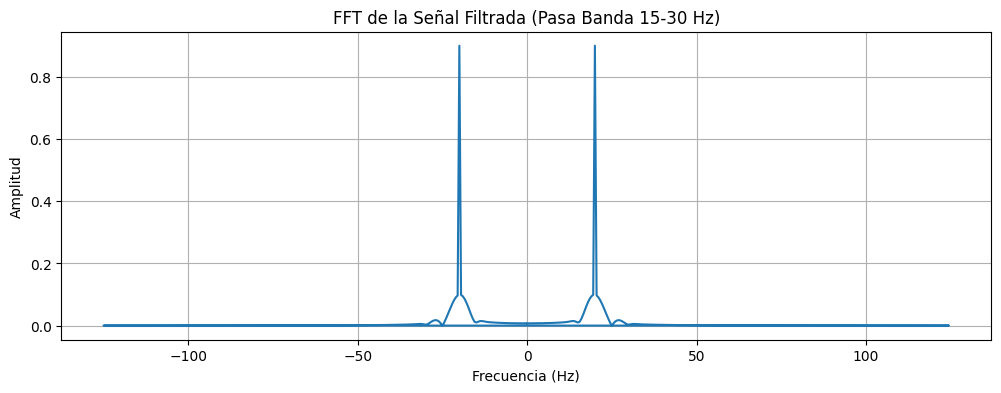

In [97]:
#FFT de la señal compuesta filtrada
plot_fft(filtered_composite_signal, fs_new, 'FFT de la Señal Filtrada (Pasa Banda 15-30 Hz)')

Ejercicio 2

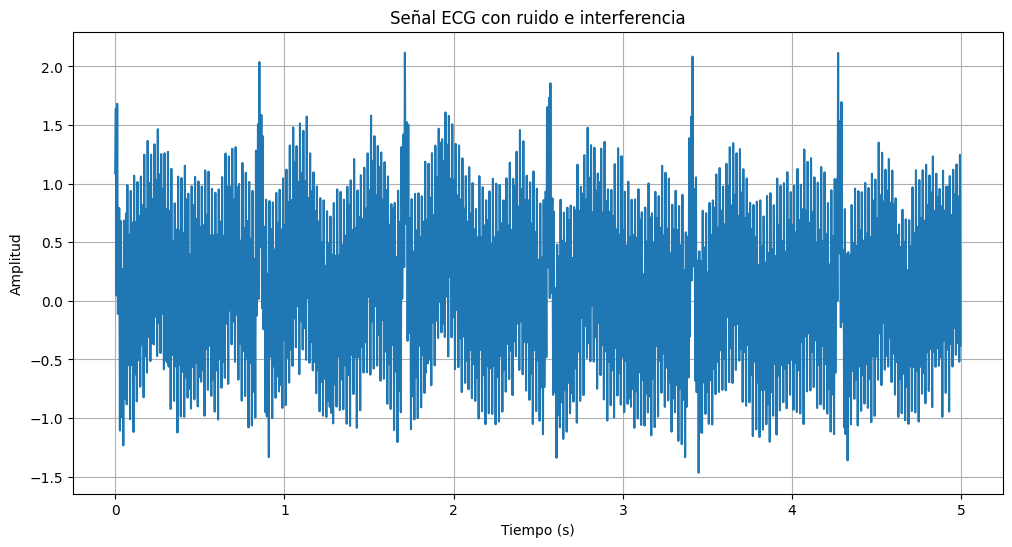

In [98]:
ecg_duration = 5
sampling_rate = 250

#Generando la señal con neurokit
ecg = nk.ecg_simulate(duration=ecg_duration, sampling_rate=sampling_rate, noise=0.2)

#Para el rudio blanco
ecg += np.random.normal(0, 0.1, len(ecg))  # Add Gaussian noise

#Alta interferencia
t = np.linspace(0, ecg_duration, len(ecg), endpoint=False)
interference_freq = 100 # Frecuencia de la interferencia
high_interference = np.sin(2 * np.pi * interference_freq * t)

composite_signal_new = ecg + high_interference

plt.figure(figsize=(12, 6))
plt.plot(t, composite_signal_new)
plt.title('Señal ECG con ruido e interferencia')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

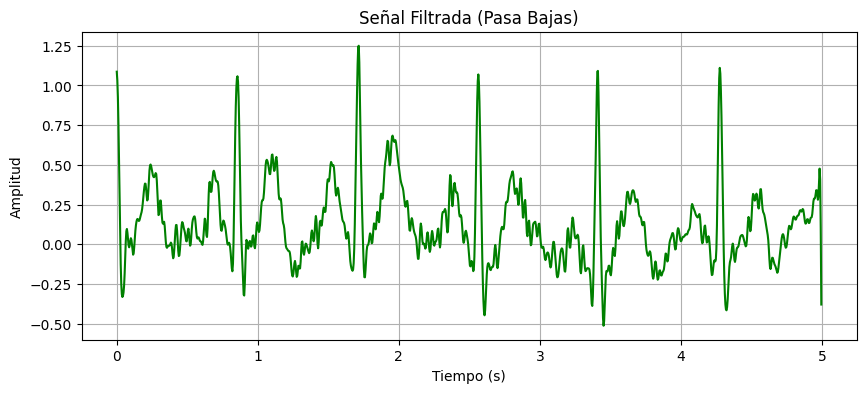

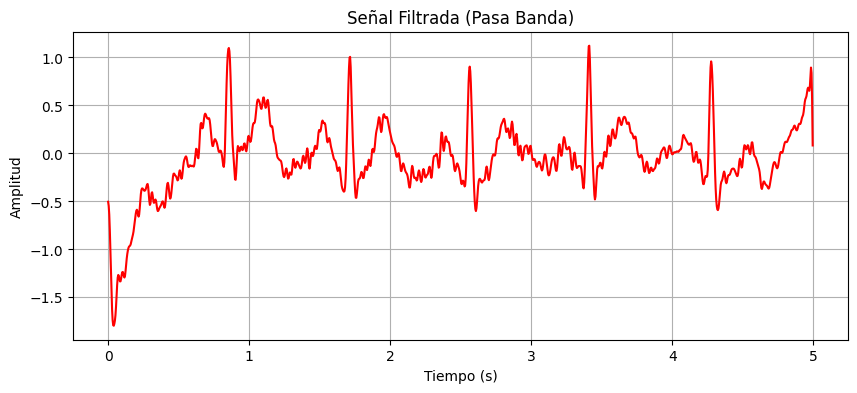

In [99]:
from scipy.signal import butter, filtfilt

#Filtro Butterworth Pasabajas
#Parametros
lowpass_cutoff = 40
filter_order = 4     # Orden del filtro

#Diseño del filtro
b_lp, a_lp = butter(filter_order, lowpass_cutoff, btype='low', fs=sampling_rate)

#Aplicando el filtro pasa bajas
filtered_lowpass_signal = filtfilt(b_lp, a_lp, composite_signal_new)

# Plotting the Lowpass Filtered Signal
plt.figure(figsize=(10, 4))
plt.plot(t, filtered_lowpass_signal, color='green')
plt.title('Señal Filtrada (Pasa Bajas)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

#Filtro Butterworth pasabandas
bandpass_lowcut = 0.5
bandpass_highcut = 40
filter_order_bp = 4

#Diseño del filtro
b_bp, a_bp = butter(filter_order_bp, [bandpass_lowcut, bandpass_highcut], btype='band', fs=sampling_rate)

#Aplicando el filtro
filtered_bandpass_signal = filtfilt(b_bp, a_bp, composite_signal_new)

#Plot
plt.figure(figsize=(10, 4))
plt.plot(t, filtered_bandpass_signal, color='red')
plt.title('Señal Filtrada (Pasa Banda)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()



Ejercicio3

In [100]:
from scipy.signal import medfilt

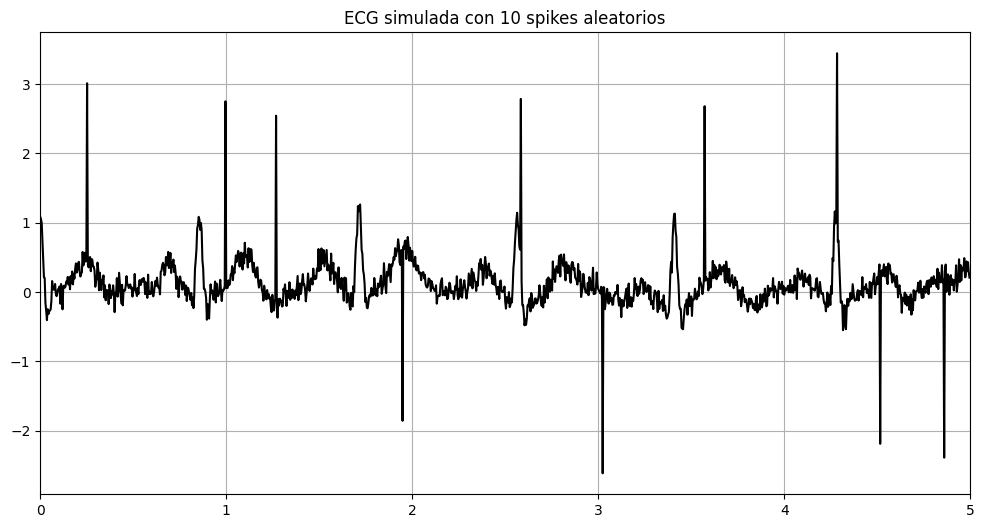

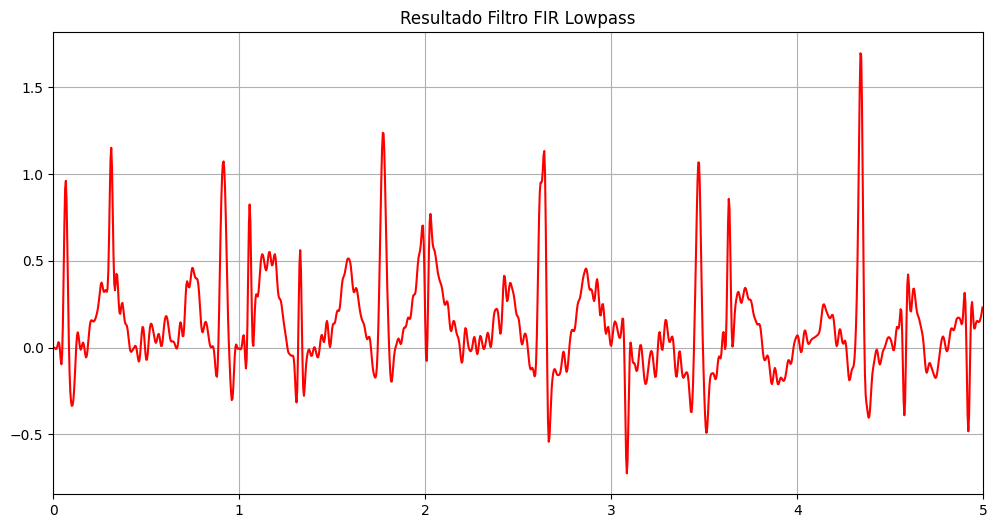

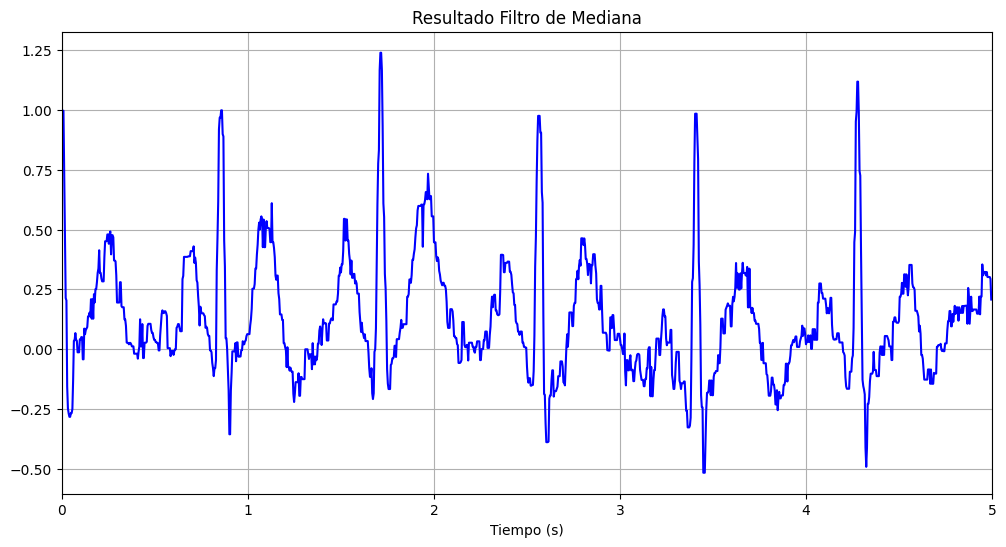

In [101]:
#Creamos copia del ecg e introducimos 10 spikes aleatorios
ecg_spikes = ecg.copy()
num_spikes = 10
spike_indices = np.random.choice(len(ecg_spikes), num_spikes, replace=False)
for idx in spike_indices:
    ecg_spikes[idx] += np.random.choice([-2.5, 2.5])  #Picos abruptos de gran amplitud

#Aplicando filtro pasabajas
b_fir = firwin(numtaps=31, cutoff=35, fs=sampling_rate)
ecg_fir = lfilter(b_fir, 1.0, ecg_spikes)

#Filtro de Mediana
ecg_median_out = medfilt(ecg_spikes, 5)

#Plot
plt.figure(figsize=(12, 6))
plt.plot(t, ecg_spikes, color='black')
plt.title('ECG simulada con 10 spikes aleatorios')
plt.xlim(0, 5)
plt.grid(True)

plt.figure(figsize=(12, 6))
plt.plot(t, ecg_fir, color='red')
plt.title('Resultado Filtro FIR Lowpass')
plt.xlim(0, 5)
plt.grid(True)

plt.figure(figsize=(12, 6))
plt.plot(t, ecg_median_out, color='blue')
plt.title('Resultado Filtro de Mediana')
plt.xlim(0, 5)
plt.xlabel('Tiempo (s)')
plt.grid(True)

#El filtro de mediana funciona mejor para eliminar los spikes aleatorios ya que
#es un filtro no lineal que descarta valores atípicos extremos.
#En cambio, el filtro FIR es lineal e intenta promediar los valores para suavizar
#la señal, pero ello puede dispersar el ruido y generar pequeñas oscilaciones

Ejercicio 4

In [102]:
from scipy.signal import iirnotch

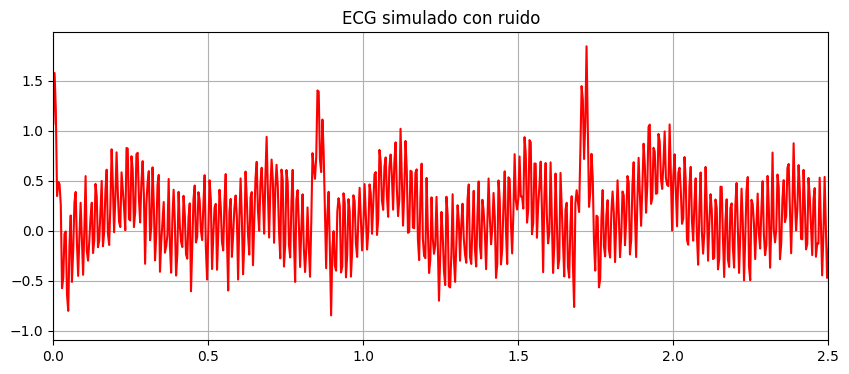

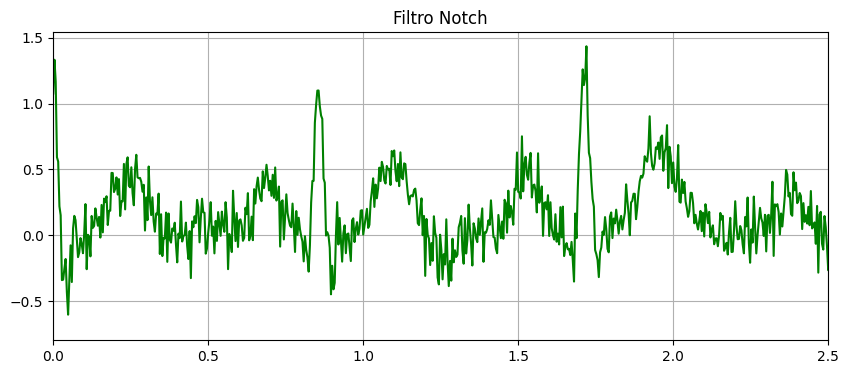

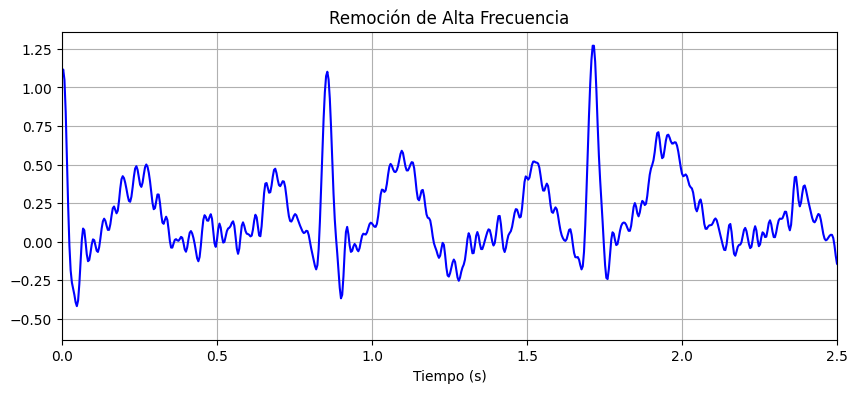

In [103]:
#Simulando la señal ECG
noise_60hz = 0.4 * np.sin(2 * np.pi * 60 * t)
white_noise = np.random.normal(0, 0.08, size=len(t))
ecg_4 = ecg + noise_60hz + white_noise

#Filtro Notch para 60Hz
f0 = 60.0   #Frecuencia a eliminar
Q = 30.0    #Factor de calidad
b_notch, a_notch = iirnotch(f0, Q, fs=sampling_rate)
ecg_notch = filtfilt(b_notch, a_notch, ecg_4)

#Filtri pasa bajas para eliminar ruido de alta frecuencia
b4, a4 = butter(N=4, Wn=40, btype='low', fs=sampling_rate)
ecg_final = filtfilt(b4, a4, ecg_notch)

#Plots
plt.figure(figsize=(10, 4))
plt.plot(t, ecg_4, color='red')
plt.title('ECG simulado con ruido')
plt.xlim(0, 2.5)
plt.grid(True)

plt.figure(figsize=(10, 4))
plt.plot(t, ecg_notch, color='green')
plt.title('Filtro Notch')
plt.xlim(0, 2.5)
plt.grid(True)

plt.figure(figsize=(10, 4))
plt.plot(t, ecg_final, color='blue')
plt.title('Remoción de Alta Frecuencia')
plt.xlim(0, 2.5)
plt.xlabel('Tiempo (s)')
plt.grid(True)


Ejercicio 5

In [104]:
from scipy.signal import correlate

Delay respiración: -67
Delay acelerómetro: 111


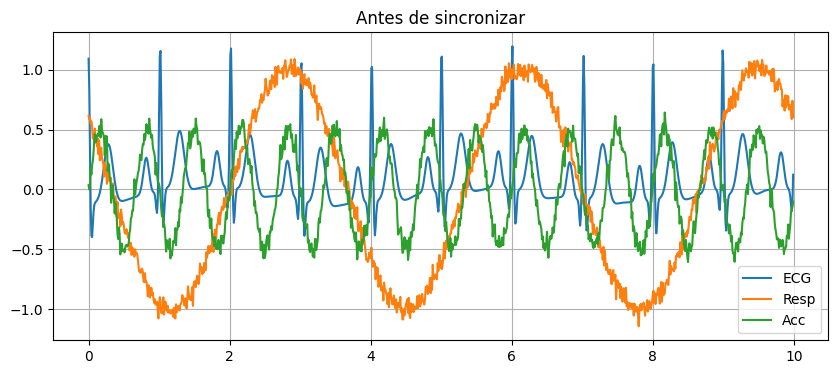

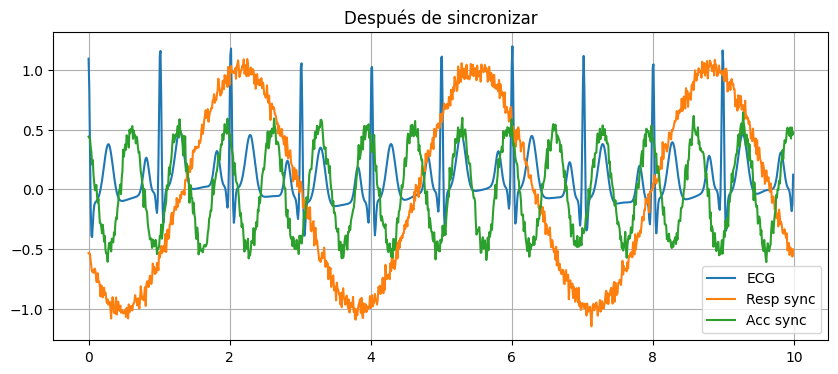

In [108]:
#Frecuencia de muestreo y tiempo
fs = 100
t = np.linspace(0, 10, fs * 10, endpoint=False)

#Generando las señales
sig_ecg = nk.ecg_simulate(duration=10, sampling_rate=fs, heart_rate=60)
#Señal de respiración
sig_resp = np.sin(2 * np.pi * 0.3 * t)
#Señal de acelerómetro
sig_acc = 0.5 * np.sin(2 * np.pi * 1.5 * t)

#Agregando delays
resp_delay = np.roll(sig_resp, 200)
acc_delay = np.roll(sig_acc, -200)

#Agregando ruido gaussiano
resp_delay = resp_delay + np.random.normal(0, 0.05, len(t))
acc_delay = acc_delay + np.random.normal(0, 0.05, len(t))

#Correlación ECG vs respiración
corr_resp = correlate(sig_ecg, resp_delay)
#Encontrar el delay estimado
delay_resp = np.argmax(corr_resp) - len(sig_ecg)
# Correlación ECG vs acelerómetro
corr_acc = correlate(sig_ecg, acc_delay)
#Delay estimado
delay_acc = np.argmax(corr_acc) - len(sig_ecg)

#Corregir desplazamiento
resp_sync = np.roll(resp_delay, delay_resp)
acc_sync = np.roll(acc_delay, delay_acc)

#Mostrar delays encontrados
print("Delay respiración:", delay_resp)
print("Delay acelerómetro:", delay_acc)

#Plots
plt.figure(figsize=(10,4))
plt.plot(t, sig_ecg, label="ECG")
plt.plot(t, resp_delay, label="Resp")
plt.plot(t, acc_delay, label="Acc")
plt.title("Antes de sincronizar")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(t, sig_ecg, label="ECG")
plt.plot(t, resp_sync, label="Resp sync")
plt.plot(t, acc_sync, label="Acc sync")
plt.title("Después de sincronizar")
plt.legend()
plt.grid()
plt.show()

Ejercicio 6

In [106]:
from scipy.signal import resample

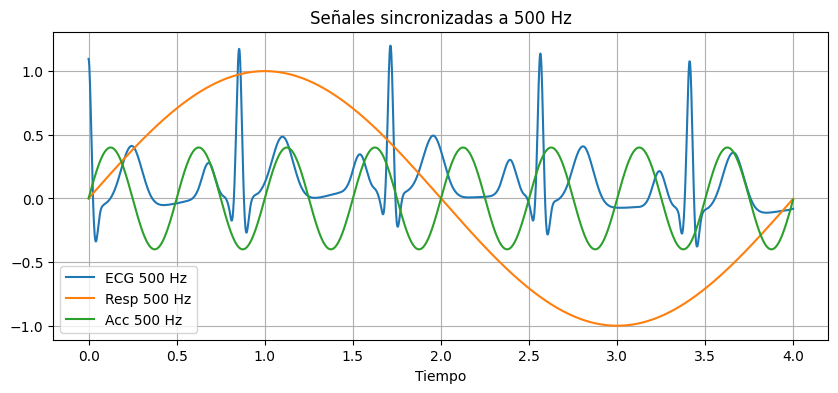

In [107]:
#Frecuencias de muestreo
duration = 4
fs_ecg = 500
fs_resp = 100
fs_acc = 200

#Tiempo para cada señal
t_ecg = np.linspace(0, duration, fs_ecg*duration, endpoint=False)
t_resp = np.linspace(0, duration, fs_resp*duration, endpoint=False)
t_acc = np.linspace(0, duration, fs_acc*duration, endpoint=False)

#Señal ECG simulada
ecg_orig = nk.ecg_simulate(duration=duration, sampling_rate=fs_ecg)
#Señal respiración
resp_orig = np.sin(2*np.pi*0.25*t_resp)
#Señal acelerómetro
acc_orig = 0.4*np.sin(2*np.pi*2*t_acc)

#Llevando todas las señales a 500Hz
fs_target = 500
num_samples = fs_target * duration

ecg_resampled = resample(ecg_orig, num_samples)
resp_resampled = resample(resp_orig, num_samples)
acc_resampled = resample(acc_orig, num_samples)
#Nuevo tiempo
t_new = np.linspace(0, duration, num_samples, endpoint=False)

#Plot
plt.figure(figsize=(10,4))
plt.plot(t_new, ecg_resampled, label="ECG 500 Hz")
plt.plot(t_new, resp_resampled, label="Resp 500 Hz")
plt.plot(t_new, acc_resampled, label="Acc 500 Hz")
plt.title("Señales sincronizadas a 500 Hz")
plt.xlabel("Tiempo")
plt.legend()
plt.grid()
plt.show()